**What happens inside a pipeline a function?**

**Pipeline has 3 stages**

-tokenizer-model-post processing

raw text->input IDs->Logits->Predictions


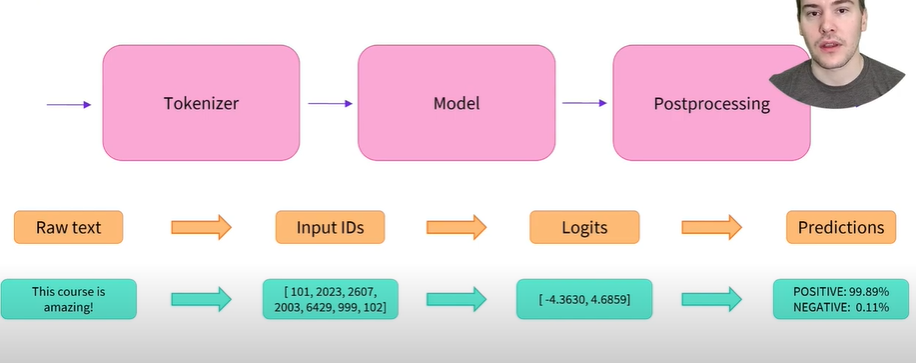

In [2]:
from transformers import pipeline
classifier=pipeline("sentiment-analysis")
classifier([
    "I have been waiting for this course for my whole life.",
    "I hate this so much",
])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9768922328948975},
 {'label': 'NEGATIVE', 'score': 0.9995144605636597}]

**Tokenizer**


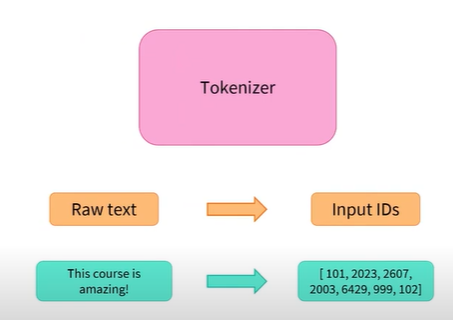


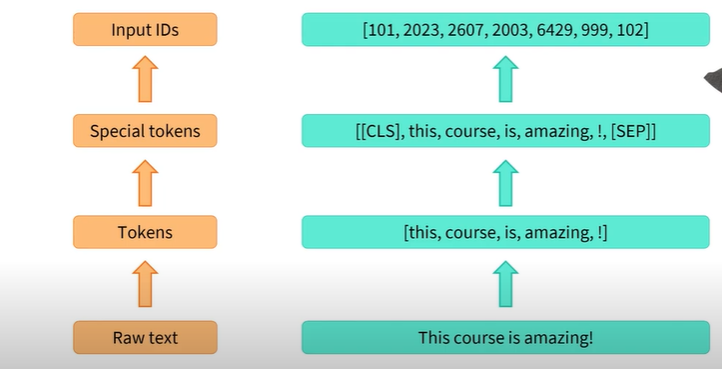

In [3]:
from transformers import AutoTokenizer
checkpoint="distilbert-base-uncased-finetuned-sst-2-english"
tokenizer=AutoTokenizer.from_pretrained(checkpoint)
raw_inputs=[
    "I have been waiting for this course for my whole life.",
    "I hate this so much"

]
inputs= tokenizer (raw_inputs,padding=True,truncation=True,return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

**Model**

the automodel class loads a model without its pretrained head

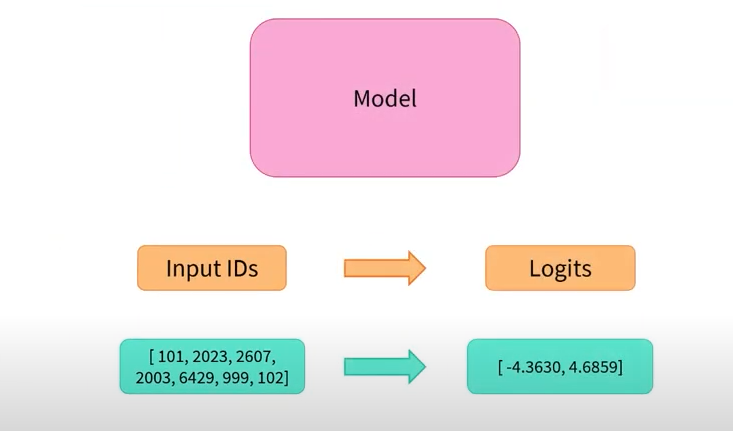

In [5]:
from transformers import AutoModel

checkpoint= "distilbert-base-uncased-finetuned-sst-2-english"
model= AutoModel.from_pretrained(checkpoint)
outputs=model(**inputs)
print(outputs.last_hidden_state.shape)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

torch.Size([2, 14, 768])


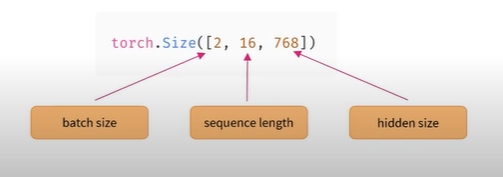

In [8]:
#automodel classification
from transformers import AutoModelForSequenceClassification
checkpoint="distilbert-base-uncased-finetuned-sst-2-english"
model=AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs=model(**inputs)
print(outputs.logits)

tensor([[-1.9004,  1.8438],
        [ 4.2141, -3.4158]], grad_fn=<AddmmBackward0>)


**Post Processing**

convert logits into probilities
there'sapplied a **softmax layer**

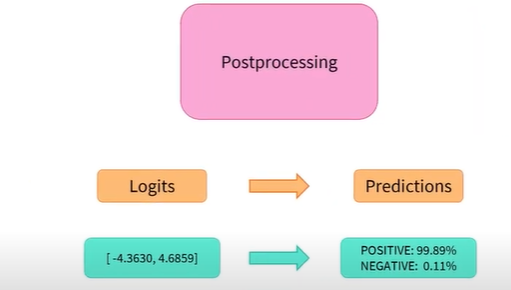


In [9]:
import torch
predictions=torch.nn.functional.softmax(outputs.logits,dim=-1)
print(predictions)

tensor([[2.3108e-02, 9.7689e-01],
        [9.9951e-01, 4.8549e-04]], grad_fn=<SoftmaxBackward0>)
